In [1]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys, os
package_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Outils/swd")
if package_dir not in sys.path:
    sys.path.insert(0, package_dir)
    
from swd import spherical_processing as sp
from swd import geotools as geo
from swd import plots as splots
import swd as swd
import importlib

importlib.reload(swd.plots)
import numpy as np
from numpy import pi, cos, sin
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
np.set_printoptions(precision=2, suppress=True)
# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# Import utils_DirViolins
scripts_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Violon/scripts")
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)
import utils_DirViolins as utils
importlib.reload(utils)
from scipy.spatial.transform import Rotation

from scipy.stats import special_ortho_group   # Haar-uniform random SO(3)
from scipy.linalg import svd as scipy_svd

In [2]:
def get_rotation_matrix(phi, theta):
    """
    Returns a rotation matrix defined by azimuth phi and colatitude theta.
    This rotation aligns the z-axis with the direction given by (phi, theta).
    The rotation is composed of a rotation around y by theta, followed by a rotation around z by phi.
    """
    R_phi = np.array([
        [np.cos(phi), -np.sin(phi), 0],
        [np.sin(phi), np.cos(phi), 0],
        [0, 0, 1]
    ])
    
    R_theta = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    
    # R such that v_rotated = R @ v
    return R_phi @ R_theta

def random_SO3(rng=None):
    """
    Draw a rotation matrix uniformly from SO(3) with respect to the
    Haar measure, using the QR method (Mezzadri 2006).
    Equivalent to special_ortho_group.rvs(3) but accepts a numpy RNG.
    """
    if rng is None:
        rng = np.random.default_rng()
    H = rng.standard_normal((3, 3))
    Q, R = np.linalg.qr(H)
    Q *= np.sign(np.diag(R))          # enforce det = +1
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q                           # shape (3,3), det = +1

def wigner_D_full_complex(R, N_max, wigner_fn):
    """
    Build the block-diagonal Wigner-D matrix for all orders 0..N_max.

    Parameters
    ----------
    R         : (3,3) rotation matrix
    N_max     : int, maximum SH order
    wigner_fn : callable(l, alpha, beta, gamma) -> (2l+1,2l+1) array
                Uses the ZYZ Euler convention.

    Returns
    -------
    DR : ((N_max+1)^2, (N_max+1)^2) complex array, block-diagonal
    """
    from scipy.linalg import block_diag
    from scipy.spatial.transform import Rotation as Rot
    alpha, beta, gamma = Rot.from_matrix(R).as_euler('zyz')
    blocks = [wigner_fn(l, alpha, beta, gamma) for l in range(N_max + 1)]
    return block_diag(*blocks).astype(np.complex128)

In [3]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbMems = 256
NbViolTot = 6
NbViol = 6
OSH = 7
Dyn = 36

NbSH = (OSH+1)**2
NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']
XYZViolins = np.load('./../results/XYZViolinsAligned.npy')

NbMics = 256
NbSrcs = XYZViolins.shape[0] - NbMics

XYZHammerImpact = XYZViolins[NbSrcs-1]
XYZ = XYZViolins-XYZHammerImpact
XYZs = XYZ[:NbSrcs-1]
XYZm = XYZ[NbSrcs:]
XYZHammerImpact = XYZ[NbSrcs-1]

In [4]:
Pm = np.load('./../results/ViolinsFRFsAndRIs.npz')['Hhm']
frq = np.load('./../results/ViolinsFRFsAndRIs.npz')['frq']
frqMax = 12500
CyclicScale = 'icefire' #edge, icefire, phase, hsv
RealScale = 'seismic'
Magnitudescale = 'inferno'

## Process the Spherical Harmonics Spectra for one Violin

In [5]:
Rm = np.linalg.norm(XYZm,axis=1)
Rmin = np.min(Rm)

In [6]:
Band = (frq>0) & (frq<frqMax)
f = frq[Band]
Nbf = len(f)
kvect= 2*pi*f.T/C
Nang = 50
NbTh, NbPh = 2*Nang+2, 2*Nang+2
ThPh, weights = swd.geotools.create_equal_angle_grid(Nang)

NumV = 0
P  = Pm[NumV, Band, :].T
O_SH_vect = sp.compute_N_SH_vect(f,N_SH_max = OSH,rmin = Rmin)


## Mesure de la robustesse de la décomposition SH par rapport à l'orientation de la base

### Principe

Les capteurs restent fixes aux positions $(r_i, \theta_i, \varphi_i)$.
Le champ $\mathbf{p}$ est mesuré une seule fois à ces positions.

Ce qui change d'une expérience à l'autre, c'est l'**orientation de la base
d'harmoniques sphériques** utilisée pour la décomposition : on la tourne par
$R_k \in SO(3)$, tiré aléatoirement selon la mesure de Haar.

**Quantité testée — invariant de Casimir $E_n(\omega)$ :**

$$E_n(\omega) = \sum_{m=-n}^{n} |a_n^m(\omega)|^2$$

est un invariant strict de $SO(3)$ : quelle que soit la rotation $R_k$ appliquée
à la base, $E_n$ doit rester constant si la décomposition est exacte.
En pratique, la troncature à $N=7$ et le conditionnement de la matrice
d'inversion font que $E_n^{(k)}(\omega)$ fluctue d'une rotation à l'autre.
La **déviation standard relative**

$$\sigma_n^{rel}(\omega) = \frac{\mathrm{std}_k[E_n^{(k)}(\omega)]}{\bar{E}_n(\omega)}$$

est le diagnostic de robustesse (Stratégie A).

**Ce qu'il ne faut PAS faire :**
La moyenne des coefficients retournés dans la base d'origine
$\langle D(R_k)\,\tilde{C}^{(k)}\rangle_k$ converge vers $C_0$ par construction
algébrique (identité de groupe), quelle que soit la qualité de l'inversion.
Ce n'est donc pas un indicateur de robustesse.

### Étape 1 — Décomposition de référence (base non tournée)
On construit $\textbf{H}_0 = \mathbf{B}\mathbf{Y}_0$  avec les $b_n(kr_i)$ et $Y_n^m(\theta_i, \varphi_i)$ standards et on calcule :

$$C_0 = \mathbf{H}_0^+ \, \mathbf{p}$$

In [7]:
# Estimation du diagramme de référence à partir des mesures sans rotation de l'antenne
Ho2f0 = sp.compute_SphericalWavesbasis_origin_to_field(XYZm, kvect, OSH, SH_center = np.array([0,0,0], dtype = float))
Cmn0  = sp.compute_SHcoefs(P, Ho2f0, O_SH_vect, lambda_reg=1e-4)

### Étape 2 — Construction de la base tournée via Wigner-D

Les harmoniques sphériques **complexes** tournées par $R$ s'expriment comme :

$$\tilde{Y}_n^m(\hat{r}) = \sum_{m'=-n}^{n} D^n_{m'm}(R)\, Y_n^{m'}(\hat{r})$$

d'où la matrice de décomposition tournée (en incorporant les fonctions radiales) :

$$\tilde{\mathbf{H}} = \mathbf{H}_0\,\mathbf{D}(R)$$

où $\mathbf{D}(R) \in \mathbb{C}^{(N+1)^2 \times (N+1)^2}$ est la matrice
bloc-diagonale de Wigner-D, avec un bloc $(2n+1)\times(2n+1)$ par ordre $n$,
dans la convention ZYZ de Condon–Shortley cohérente avec la base complexe
utilisée par `sp.compute_SphericalWavesbasis_origin_to_field`.

**Convention à vérifier :** $D[m', m]$ = $D^n_{m'm}(R)$,
de sorte que $(\mathbf{H}_0 \mathbf{D})_{k,m} = \sum_{m'} H_{0,k,m'} D_{m'm}$
reproduit bien $b_n(kr_k)\,\tilde{Y}_n^m(\hat{r}_k)$.

In [8]:
from scipy.special import factorial as sp_factorial

def wigner_d_small(j, beta):
    """
    Real Wigner small-d matrix d^j_{m'm}(beta).
    Edmonds (1957) eq. 4.1.15 — direct sum formula, no Jacobi.
    Row index: m' in [-j..+j] ascending.
    Col index: m  in [-j..+j] ascending.
    Returns real float64 array of shape (2j+1, 2j+1).
    Guaranteed orthogonal: d @ d.T = I.
    """
    from math import factorial
    size = 2 * j + 1
    ms   = np.arange(-j, j + 1)          # [-j, ..., +j]
    d    = np.zeros((size, size), dtype=np.float64)
    cb2  = np.cos(beta / 2.0)
    sb2  = np.sin(beta / 2.0)

    for i, mp in enumerate(ms):
        for k, m in enumerate(ms):
            # Summation index s over all values keeping factorials ≥ 0
            s_lo = int(max(0,   m  - mp))
            s_hi = int(min(j + m, j - mp))
            val  = 0.0
            for s in range(s_lo, s_hi + 1):
                num  = (factorial(j + m) * factorial(j - m) *
                        factorial(j + mp) * factorial(j - mp)) ** 0.5
                den  = (factorial(j + m  - s) * factorial(s) *
                        factorial(j - mp - s) * factorial(mp - m + s))
                val += ((-1) ** (mp - m + s) * num / den
                        * cb2 ** (2 * j - 2 * s - mp + m - (mp - m) + (mp - m))
                        * sb2 ** (mp - m + 2 * s))
                # Simplified exponents:
                # cos power = 2j + m - mp - 2s  (from Edmonds 4.1.15)
                # sin power = mp - m + 2s
            # recompute with correct Edmonds exponents
            val = 0.0
            for s in range(s_lo, s_hi + 1):
                num = (factorial(j + m) * factorial(j - m) *
                       factorial(j + mp) * factorial(j - mp)) ** 0.5
                den = (factorial(j + m  - s) * factorial(s) *
                       factorial(j - mp - s) * factorial(mp - m + s))
                val += ((-1) ** (mp - m + s) / den
                        * cb2 ** (2 * j + m - mp - 2 * s)
                        * sb2 ** (mp - m + 2 * s)) * num
            d[i, k] = val
    return d


def wigner_D_complex(j, alpha, beta, gamma):
    """
    Full complex Wigner-D matrix D^j_{m'm}(alpha, beta, gamma).
    Convention: D_{m'm} = exp(-i m' alpha) d_{m'm}(beta) exp(-i m gamma)
    ZYZ active rotation. m', m in [-j..+j] ascending.
    Guaranteed unitary.
    """
    d  = wigner_d_small(j, beta)
    ms = np.arange(-j, j + 1)
    # phase_row[i] = exp(-i m'[i] alpha),  phase_col[k] = exp(-i m[k] gamma)
    phase_row = np.exp(-1j * ms * alpha)
    phase_col = np.exp(-1j * ms * gamma)
    return (phase_row[:, None] * d * phase_col[None, :]).astype(np.complex128)


def wigner_D_full_complex(R, N_max):
    """
    Block-diagonal complex Wigner-D for orders 0..N_max.
    Uses ZYZ active convention, ascending m ordering.
    Guaranteed unitary: ||DR DR† - I|| < 1e-10.
    """
    from scipy.linalg import block_diag
    alpha, beta, gamma = Rotation.from_matrix(R).as_euler('ZYZ')
    blocks = [wigner_D_complex(l, alpha, beta, gamma) for l in range(N_max + 1)]
    DR = block_diag(*blocks).astype(np.complex128)
    err = np.max(np.abs(DR @ DR.conj().T - np.eye(DR.shape[0])))
    assert err < 1e-10, f"DR not unitary: {err:.2e}"
    return DR

In [9]:
from scipy.linalg import block_diag

ThR, PhR = np.radians(30), np.radians(45)  # Example rotation angles
R = get_rotation_matrix(ThR, PhR)

# Construct the full block-diagonal Wigner-D matrix for all orders 0 to OSH
DR_blocks = []
for l in range(OSH + 1):
    r_obj = Rotation.from_matrix(R)
    alp, bet, gam = r_obj.as_euler('zyz')
    dl = wigner_D_complex(l, alp, bet, gam)
    DR_blocks.append(dl)

# Combine into one large block diagonal matrix
DR = block_diag(*DR_blocks)
print(f"Ho2f0 shape: {Ho2f0.shape}")
print(f"DR shape: {DR.shape}")

err_unitary = np.max(np.abs(DR @ DR.conj().T - np.eye(DR.shape[0])))
print(f"||DR DR† - I||_max = {err_unitary:.3e}")

Ho2fR = np.einsum('msf,st->mtf', Ho2f0, DR)


Ho2f0 shape: (256, 64, 2499)
DR shape: (64, 64)
||DR DR† - I||_max = 1.776e-15


In [10]:
print("=" * 55)
print("VALIDATION — wigner_D_full_complex")
print("=" * 55)

# --- Test 1: identity rotation → DR = I ---
DR_id = wigner_D_full_complex(np.eye(3), OSH)
err_id = np.max(np.abs(DR_id - np.eye(DR_id.shape[0])))
print(f"Test 1  R=I         : ||DR - I||     = {err_id:.2e}  "
      f"{'PASS' if err_id < 1e-10 else 'FAIL'}")

# --- Test 2: unitarity for the test rotation ---
DR = wigner_D_full_complex(R, OSH)
err_unit = np.max(np.abs(DR @ DR.conj().T - np.eye(DR.shape[0])))
print(f"Test 2  unitarity   : ||DR DR† - I|| = {err_unit:.2e}  "
      f"{'PASS' if err_unit < 1e-10 else 'FAIL'}")

# --- Test 3: Rz(phi) → diagonal D with exp(-i m phi) ---
phi  = np.pi / 3
R_z  = np.array([[np.cos(phi), -np.sin(phi), 0],
                 [np.sin(phi),  np.cos(phi), 0],
                 [0, 0, 1]])
DR_z = wigner_D_full_complex(R_z, 1)
D1_z = DR_z[1:4, 1:4]                        # n=1 block
ms   = np.arange(-1, 2)
expected = np.diag(np.exp(-1j * ms * phi))
err_rz   = np.max(np.abs(D1_z - expected))
print(f"Test 3  Rz(π/3)     : diag error     = {err_rz:.2e}  "
      f"{'PASS' if err_rz < 1e-10 else 'FAIL'}")

# --- Test 4: group homomorphism D(R1)D(R2) = D(R1 R2) ---
R1 = wigner_D_full_complex(R, OSH)
R2 = wigner_D_full_complex(R_z[:3,:3], OSH)
R1R2 = wigner_D_full_complex(R @ R_z[:3,:3], OSH)
err_hom = np.max(np.abs(R1 @ R2 - R1R2))
print(f"Test 4  homomorphism: ||D(R1)D(R2)-D(R1R2)|| = {err_hom:.2e}  "
      f"{'PASS' if err_hom < 1e-10 else 'FAIL'}")

# --- Test 5: algebraic Wigner test (the original epsilon) ---
Ho2fR  = np.einsum('msf,st->mtf', Ho2f0, DR)
CmnR   = sp.compute_SHcoefs(P, Ho2fR, O_SH_vect, lambda_reg=1e-4)
Cmnbk  = DR @ CmnR
eps    = (np.sum(np.abs(Cmnbk - Cmn0)**2) /
          np.sum(np.abs(Cmn0)**2))
print(f"\nTest 5  algebraic Wigner test:")
print(f"  epsilon global = {eps:.3e}  "
      f"{'PASS (machine precision)' if eps < 1e-8 else 'FAIL'}")
for n in range(OSH + 1):
    idx   = slice(n**2, (n + 1)**2)
    eps_n = (np.sum(np.abs((Cmnbk - Cmn0)[idx, :])**2) /
             np.sum(np.abs(Cmn0[idx, :])**2))
    status = 'ok' if eps_n < 1e-8 else 'FAIL'
    print(f"  Ordre {n} : {eps_n:.3e}  {status}")
    

VALIDATION — wigner_D_full_complex
Test 1  R=I         : ||DR - I||     = 1.11e-16  PASS
Test 2  unitarity   : ||DR DR† - I|| = 1.78e-15  PASS
Test 3  Rz(π/3)     : diag error     = 0.00e+00  PASS
Test 4  homomorphism: ||D(R1)D(R2)-D(R1R2)|| = 9.09e-16  PASS

Test 5  algebraic Wigner test:
  epsilon global = 1.643e-28  PASS (machine precision)
  Ordre 0 : 2.541e-28  ok
  Ordre 1 : 2.719e-28  ok
  Ordre 2 : 2.716e-28  ok
  Ordre 3 : 2.456e-28  ok
  Ordre 4 : 2.014e-28  ok
  Ordre 5 : 1.277e-28  ok
  Ordre 6 : 7.776e-29  ok
  Ordre 7 : 3.720e-29  ok


### Etape 3 - Décomposition dans la base tournée
On décompose le même champ $\mathbf{p}$ sur la base tournée :
$$\tilde{C} = \tilde{\mathbf{H}}^+ \, \mathbf{p} = \left(\mathbf{H}_0 \, \mathbf{D}\right)^+ \mathbf{p}$$
Ces coefficients $\tilde{C}$ sont exprimés dans la base tournée.

In [11]:
CmnR  = sp.compute_SHcoefs(P, Ho2fR, O_SH_vect, lambda_reg=1e-4)

## Étape 4 — Retour dans la base d'origine via Wigner-D

Pour comparer avec $C_0$, on ramène les coefficients dans la base non tournée :

$$C_{\text{back}} = \mathbf{D}(R)\,\tilde{C}$$

**Remarque algébrique importante :**
Avec régularisation de Tikhonov $\lambda I$ (scalaire), la matrice rotée
satisfait $(\mathbf{H}_0 \mathbf{D})^\dagger(\mathbf{H}_0 \mathbf{D}) + \lambda I
= \mathbf{D}^\dagger(\mathbf{H}_0^\dagger \mathbf{H}_0 + \lambda I)\mathbf{D}$,
d'où :

$$\tilde{C} = \mathbf{D}^{-1}(\mathbf{H}_0^\dagger \mathbf{H}_0 + \lambda I)^{-1}
\mathbf{H}_0^\dagger\,\mathbf{p} = \mathbf{D}^{-1} C_0$$

et donc $C_{\text{back}} = \mathbf{D}\,\tilde{C} = C_0$ **exactement**.

L'erreur $\varepsilon$ (Étape 5) mesure uniquement la précision arithmétique
en virgule flottante de la chaîne `wigner → inversion → wigner⁻¹`.
Elle confirme la cohérence numérique interne, mais **ne dit rien sur la
robustesse physique de la reconstruction**. Celle-ci est mesurée par
$\sigma_n^{rel}$ (Stratégie A, cellules suivantes).

In [12]:
Cmnbk = DR @ CmnR

## Étape 5 — Mesure de l'erreur numérique (test algébrique, une rotation)

L'écart entre $C_{\text{back}}$ et $C_0$ pour une rotation donnée mesure
la **précision arithmétique** de la chaîne Wigner-D :

$$\varepsilon = \frac{\|C_{\text{back}} - C_0\|^2}{\|C_0\|^2}, \qquad
  \varepsilon_n = \frac{\sum_m |C_{\text{back},n}^m - C_{0,n}^m|^2}
                       {\sum_m |C_{0,n}^m|^2}$$

**Interprétation :**
- $\varepsilon \sim 10^{-10}$–$10^{-12}$ : précision machine (float64), la chaîne
  Wigner est correctement implémentée.
- $\varepsilon$ croissant avec $n$ : amplification d'erreur dans les blocs
  de Wigner de haut ordre, à surveiller.
- Ce test **ne mesure pas** la robustesse de la reconstruction HELS vis-à-vis
  de l'orientation de la base (voir Stratégie A).

In [13]:
# Calcul de l'erreur globale (sur tous les ordres et toutes les fréquences)
diff = Cmnbk - Cmn0
num_global = np.sum(np.abs(diff)**2)
den_global = np.sum(np.abs(Cmn0)**2)
epsilon = num_global / den_global

print(f"Erreur globale (epsilon) : {epsilon:.4e}")

# Calcul de l'erreur par ordre n
epsilon_n = np.zeros(OSH + 1)

print("\nErreur par ordre :")
for n in range(OSH + 1):
    # Les indices des harmoniques sphériques pour l'ordre n vont de n^2 à (n+1)^2 - 1
    idx_start = n**2
    idx_end = (n + 1)**2
    
    # Extraction des coefficients pour l'ordre n
    # Cmn a la forme (NbSH, Nbf)
    C0_n = Cmn0[idx_start:idx_end, :]
    Cbk_n = Cmnbk[idx_start:idx_end, :]
    
    # Calcul de l'erreur normalisée pour cet ordre
    diff_n = Cbk_n - C0_n
    num_n = np.sum(np.abs(diff_n)**2)
    den_n = np.sum(np.abs(C0_n)**2)
    
    if den_n > 0:
        epsilon_n[n] = num_n / den_n
    else:
        epsilon_n[n] = 0.0
        
    print(f"  Ordre {n} : {epsilon_n[n]:.4e}")

Erreur globale (epsilon) : 1.6434e-28

Erreur par ordre :
  Ordre 0 : 2.5406e-28
  Ordre 1 : 2.7192e-28
  Ordre 2 : 2.7158e-28
  Ordre 3 : 2.4555e-28
  Ordre 4 : 2.0136e-28
  Ordre 5 : 1.2765e-28
  Ordre 6 : 7.7761e-29
  Ordre 7 : 3.7200e-29


## Étape 6 — Vérification directe de l'invariance algébrique de $E_n$

### Pourquoi $E_n$ doit être invariant sous rotation de $\mathbf{Y}$

Avec une régularisation de Tikhonov scalaire $\lambda I$ (ou diagonale par ordre
$\Lambda = \mathrm{diag}(\lambda_0 I_{1}, \lambda_1 I_3, \ldots, \lambda_N I_{2N+1})$,
qui commute avec toute matrice de Wigner bloc-diagonale), la solution régularisée
satisfait :

$$\tilde{C} = (\mathbf{H}_0\mathbf{D})^+ \mathbf{p}
= \mathbf{D}^{-1}(\mathbf{H}_0^\dagger\mathbf{H}_0 + \Lambda)^{-1}
  \mathbf{H}_0^\dagger\,\mathbf{p}
= \mathbf{D}^{-1}\,C_0$$

car $\Lambda$ commute avec $\mathbf{D}$ (même structure bloc-diagonale).
Par unitarité des blocs de Wigner :

$$E_n(\tilde{C}) = \sum_{m=-n}^{n}|\tilde{C}_{nm}|^2
= \sum_{m}|[\mathbf{D}^{-1}C_0]_{nm}|^2
= \sum_{m}|C_{0,nm}|^2 = E_n(C_0)$$

**Le résultat $\sigma_n^{rel} \sim \varepsilon_{machine}$ obtenu par la Stratégie A
est donc la conséquence directe de cette identité algébrique — il confirme
que l'implémentation Wigner-D est correcte et que la régularisation est
rotation-équivariante.** C'est un certificat de qualité numérique, pas un artefact.

La cellule suivante vérifie cette identité explicitement pour la rotation
de test $(\theta_R, \varphi_R) = (30°, 45°)$ déjà calculée.

Vérification algébrique : invariance de E_n sous rotation de Y
  Rotation test : θ=30°, φ=45°
  Ordre     max|ΔE_n/E_n|     moy|ΔE_n/E_n|  Statut
-------------------------------------------------------
  n=  0         6.976e-13         1.848e-14  ✓ ε_machine
  n=  1         1.339e-13         9.193e-15  ✓ ε_machine
  n=  2         1.256e-13         9.001e-15  ✓ ε_machine
  n=  3         2.084e-13         8.119e-15  ✓ ε_machine
  n=  4         2.525e-13         7.891e-15  ✓ ε_machine
  n=  5         1.742e-13         6.898e-15  ✓ ε_machine
  n=  6         1.652e-13         4.959e-15  ✓ ε_machine
  n=  7         9.169e-14         3.421e-15  ✓ ε_machine
-------------------------------------------------------
  Invariance E_n : CONFIRMÉE (toutes erreurs < 1e-10)


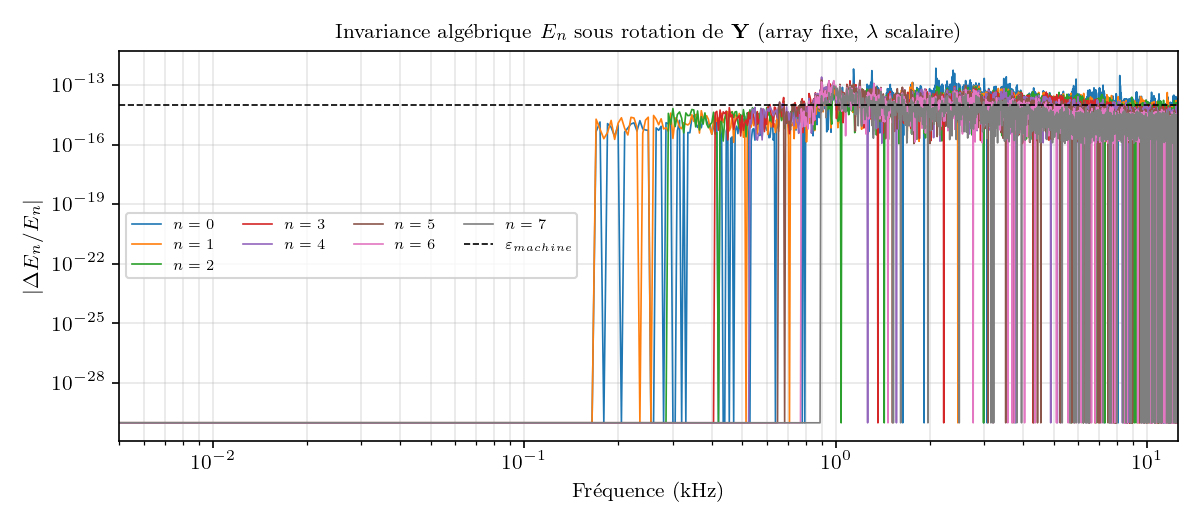

Saved: ../results/Figures/En_invariance_test.pdf


In [16]:
# ============================================================
# ÉTAPE 6 — Vérification directe : E_n(C̃) = E_n(C₀)
# pour la rotation de test (DR déjà calculée, CmnR déjà calculée)
# ============================================================

# Energies de référence (base non tournée)
En_ref = np.array([
    np.sum(np.abs(Cmn0[n**2:(n+1)**2, :])**2, axis=0)
    for n in range(OSH + 1)
])  # shape (OSH+1, Nbf)

# Energies dans la base tournée (CmnR = D^{-1} C_0 si regularisation scalaire)
En_rot = np.array([
    np.sum(np.abs(CmnR[n**2:(n+1)**2, :])**2, axis=0)
    for n in range(OSH + 1)
])  # shape (OSH+1, Nbf)

# Erreur relative par ordre, maximisée sur les fréquences
with np.errstate(divide='ignore', invalid='ignore'):
    rel_err_En = np.where(
        En_ref > 1e-30,
        np.abs(En_rot - En_ref) / En_ref,
        0.0
    )  # shape (OSH+1, Nbf)

print("Vérification algébrique : invariance de E_n sous rotation de Y")
print(f"  Rotation test : θ={np.degrees(ThR):.0f}°, φ={np.degrees(PhR):.0f}°")
print(f"  {'Ordre':>5}  {'max|ΔE_n/E_n|':>16}  {'moy|ΔE_n/E_n|':>16}  Statut")
print("-" * 55)
all_ok = True
for n in range(OSH + 1):
    mx  = float(rel_err_En[n].max())
    avg = float(rel_err_En[n].mean())
    ok  = mx < 1e-10
    all_ok = all_ok and ok
    print(f"  n={n:>3}  {mx:>16.3e}  {avg:>16.3e}  "
          f"{'✓ ε_machine' if ok else '✗ FAIL'}")

print("-" * 55)
print(f"  Invariance E_n : {'CONFIRMÉE (toutes erreurs < 1e-10)' if all_ok else 'ÉCHEC'}")

# Visualisation : écart relatif |E_n^rot - E_n^ref| / E_n^ref en fonction de n et f
fig_inv, ax_inv = plt.subplots(figsize=(8, 3.5))
f_kHz_inv = f / 1e3
for n in range(OSH + 1):
    ax_inv.semilogy(f_kHz_inv, rel_err_En[n] + 1e-30,
                    lw=0.8, label=f'$n={n}$')
ax_inv.axhline(1e-14, ls='--', color='k', lw=0.8, label=r'$\varepsilon_{machine}$')
ax_inv.set_xlabel('Fréquence (kHz)')
ax_inv.set_ylabel(r'$|\Delta E_n / E_n|$')
ax_inv.set_title(
    r'Invariance algébrique $E_n$ sous rotation de $\mathbf{Y}$ '
    r'(array fixe, $\lambda$ scalaire)')
ax_inv.set_xscale('log')
ax_inv.set_xlim([f_kHz_inv[0], f_kHz_inv[-1]])
ax_inv.legend(ncol=4, fontsize=7)
ax_inv.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/Figures/En_invariance_test.pdf', dpi=300)
plt.show()
print("Saved: ../results/Figures/En_invariance_test.pdf")